# CSE 438 — Part B, Notebook 1: SimCLR
## Self-Supervised Pretraining → Decoder Attachment → Fine-tuning → Evaluation (Tasks B–F)

**Method:** SimCLR (contrastive) &nbsp;|&nbsp; **Backbone:** ResNet-50 &nbsp;|&nbsp;
**Decoder:** DeepLabV3 ASPP head (Part A's best-performing architecture, mIoU 0.836 on this dataset)

**This notebook is the pattern for the other three.** BYOL, MAE, and DINOv2 each follow the
identical five-stage pipeline (pretrain → attach decoder → fine-tune → test → error-analyze); only
Task B's pretext task, augmentation, and (for the ViT methods) the feature-adapter in Task C change.
Read this notebook fully before adapting it — do not run it unmodified for the other methods, per
the assignment's instructions.

**Pipeline recap:**
`Input Image → SSL Encoder (frozen or fine-tuned) → Dense Patch Features → DeepLabV3 Decoder → Per-pixel Class`

**Compute-budget path used in this notebook:** Path 1 (continue SSL pretraining from a released
checkpoint) is attempted first, with a clearly-flagged fallback to Path 2 (ImageNet-supervised
init) if no SimCLR-specific checkpoint can be loaded in this environment — **you must check which
path actually ran (printed in the pretraining-setup cell) and report that choice**, not assume
Path 1 succeeded.

In [1]:
# ============================================================================
# PART 0 -- Preflight + install + imports
# ============================================================================
import socket, sys, os

def check_internet(host="pypi.org", port=443, timeout=5):
    try:
        socket.setdefaulttimeout(timeout); socket.create_connection((host, port)); return True
    except OSError:
        return False

assert check_internet(), "No internet detected -- on Kaggle: Settings -> Internet -> On."

!pip install -q --timeout 20 "lightly>=1.5" albumentations

import json, time, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as Fnn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
import albumentations as A

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
QUICK_TEST_MODE = False   # True while debugging: shrinks epochs so the whole notebook runs in minutes
print(f"Device: {DEVICE} | torch: {torch.__version__} | QUICK_TEST_MODE={QUICK_TEST_MODE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 11.3 MB/s eta 0:00:00
Device: cuda | torch: 2.10.0+cu128 | QUICK_TEST_MODE=False


**Summary —** Installed `lightly` (provides SimCLR's NT-Xent loss and, where available, pretrained
SimCLR backbones — Task B's Path-1 checkpoint source) and `albumentations`, then fixed all seeds.
`QUICK_TEST_MODE` mirrors Part A's pattern: leave it `False` for the real 50-epoch run, flip it on
only to debug the pipeline end-to-end quickly.

In [2]:
# ============================================================================
# Load the Part-B role-mapped split produced by the Data Prep notebook.
# On Kaggle, attach the Data Prep notebook's output as an Input dataset and
# it will appear under /kaggle/input/<dataset-name>/busi_partB_split.json.
# This cell searches common locations so the notebook also runs locally.
# Self-contained: imports its own dependencies so it doesn't matter if an
# earlier setup cell was skipped or the kernel was restarted.
# ============================================================================
import os
import json
import glob

CANDIDATE_PATHS = [
    "/kaggle/input/busi-partb-00-data-prep/busi_partB_split.json",  # matches your Data Prep notebook slug
    "/kaggle/input/busi-partb-data-prep/busi_partB_split.json",     # alternate slug, just in case
    "/kaggle/working/busi_partB_split.json",                        # same-session chaining
    "./busi_partB_split.json",                                      # local dev
]

SPLIT_PATH = next((p for p in CANDIDATE_PATHS if os.path.isfile(p)), None)

if SPLIT_PATH is None:
    # Glob fallback in case the attached dataset folder has a different slug
    # than any of the guesses above.
    hits = glob.glob("/kaggle/input/**/busi_partB_split.json", recursive=True)
    SPLIT_PATH = hits[0] if hits else None

if SPLIT_PATH is None:
    print("busi_partB_split.json not found. Datasets currently attached under /kaggle/input:")
    if os.path.isdir("/kaggle/input"):
        for d in os.listdir("/kaggle/input"):
            print(f"  {d} -> {os.listdir(os.path.join('/kaggle/input', d))}")
    else:
        print("  /kaggle/input does not exist in this environment.")

assert SPLIT_PATH is not None, (
    "busi_partB_split.json not found. Run the Data Prep notebook first, publish its output as a "
    "Kaggle Dataset, and attach it to this notebook via '+ Add Input'. See the printed listing "
    "above for what's currently attached."
)

with open(SPLIT_PATH) as f:
    split = json.load(f)

SEED = split["seed"]
IMG_SIZE = split["img_size"]
NUM_CLASSES = split["num_classes"]
CLASS_WEIGHTS = {int(k): v for k, v in split["class_weights"].items()}
train_records = split["roles"]["unlabelled_pretrain"]   # Task B corpus (images only)
val_records   = split["roles"]["labelled_finetune"]     # Task D labelled data
test_records  = split["roles"]["monitor_eval"]           # Task D monitoring + Task E final eval

print(f"Loaded split from: {SPLIT_PATH}")
print(f"unlabelled_pretrain: {len(train_records)} | labelled_finetune: {len(val_records)} | "
      f"monitor_eval: {len(test_records)} | img_size={IMG_SIZE} | class_weights={CLASS_WEIGHTS}")

Loaded split from: /kaggle/input/notebooks/mdfokrulakon/busi-partb-00-data-prep/busi_partB_split.json
unlabelled_pretrain: 546 | labelled_finetune: 117 | monitor_eval: 117 | img_size=512 | class_weights={0: 0.5406045513867678, 1: 6.656945255193}


**Summary —** Loaded the single source of truth for this notebook's data — `busi_partB_split.json`
— rather than re-downloading or re-splitting BUSI. Every one of the four SSL notebooks should start
with this exact cell (only the candidate dataset slug in `CANDIDATE_PATHS` might need adjusting),
guaranteeing SimCLR, BYOL, MAE, and DINOv2 all see identical unlabelled/labelled/eval partitions.

In [3]:
# ============================================================================
# FIX: busi_partB_split.json stores image paths from the Data Prep notebook's
# OWN kagglehub cache session, which does not persist across notebooks.
# Re-download BUSI here and remap every record's paths to THIS session's
# actual on-disk location, keyed by diagnosis + filename (which don't change).
# ============================================================================
import os
import kagglehub

KAGGLE_HANDLE = "aryashah2k/breast-ultrasound-images-dataset"
download_path = kagglehub.dataset_download(KAGGLE_HANDLE)

def find_data_dir(root):
    for dirpath, dirnames, _ in os.walk(root):
        lowered = {d.lower() for d in dirnames}
        if {"benign", "malignant", "normal"}.issubset(lowered):
            return dirpath
    raise FileNotFoundError(f"Could not locate benign/malignant/normal folders under {root}")

DATA_DIR = find_data_dir(download_path)
print(f"This session's DATA_DIR: {DATA_DIR}")

def remap_record(rec):
    cls_dir = os.path.join(DATA_DIR, rec["diagnosis"])
    stem = os.path.splitext(rec["filename"])[0]
    all_files = os.listdir(cls_dir)
    new_image_path = os.path.join(cls_dir, rec["filename"])
    new_mask_paths = sorted(
        os.path.join(cls_dir, f) for f in all_files
        if f.startswith(stem + "_mask") and f.lower().endswith(".png")
    )
    assert os.path.isfile(new_image_path), f"Remapped image path still missing: {new_image_path}"
    rec = dict(rec)  # don't mutate the loaded JSON in place
    rec["image_path"] = new_image_path
    rec["mask_paths"] = new_mask_paths
    return rec

train_records = [remap_record(r) for r in train_records]
val_records   = [remap_record(r) for r in val_records]
test_records  = [remap_record(r) for r in test_records]

print(f"Remapped: {len(train_records)} unlabelled, {len(val_records)} labelled_finetune, "
      f"{len(test_records)} monitor_eval — all paths verified to exist in this session.")

This session's DATA_DIR: /kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
Remapped: 546 unlabelled, 117 labelled_finetune, 117 monitor_eval — all paths verified to exist in this session.


### Task B — SimCLR Pretraining

**Pretext task:** maximize agreement between two independently-augmented views of the *same*
image relative to all other images in the batch (NT-Xent / InfoNCE loss). No class label is ever
used — the only "supervision" is the constraint that two augmented crops of one ultrasound image
should map to nearby points in representation space, while crops of *different* images should not.

**Augmentation choices for this dataset (deviating from SimCLR's original natural-image recipe):**
strong colour-jitter and Cutout are dropped because BUSI is single-channel grayscale replicated to
3 channels — colour has no diagnostic meaning here, so colour-jitter would just add noise, not a
useful invariance. Kept: `RandomResizedCrop` (viewpoint/zoom invariance — a probe can be closer or
farther from the lesion), `HorizontalFlip` (left/right orientation is arbitrary), mild
`RandomBrightnessContrast` (stands in for gain/TGC variation across machines, matching Part A's own
justification), and `GaussianBlur` (probe-focus variation).

In [4]:
# ============================================================================
# Task B -- Two-view SimCLR augmentation pipeline + Dataset.
# Self-contained: imports its own dependencies so it doesn't matter whether
# an earlier setup cell ran in this session.
# ============================================================================
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

def load_mask(mask_paths, h, w):
    combined = np.zeros((h, w), dtype=np.uint8)
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        combined = np.maximum(combined, (m > 127).astype(np.uint8))
    return combined

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def _read_rgb(image_path, size):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_LINEAR)
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

def normalize(img_rgb_uint8):
    x = img_rgb_uint8.astype(np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(x.transpose(2, 0, 1)).float()

simclr_view_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0), ratio=(0.9, 1.1), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
])

class SimCLRDataset(Dataset):
    """Yields (view1, view2) -- two independently-augmented crops of the same unlabelled image.
    No mask is ever loaded here, matching Task B's 'images only' requirement."""
    def __init__(self, records, size, transform):
        self.records, self.size, self.transform = records, size, transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        img_rgb = _read_rgb(self.records[idx]["image_path"], self.size)
        v1 = self.transform(image=img_rgb)["image"]
        v2 = self.transform(image=img_rgb)["image"]
        return normalize(v1), normalize(v2)

BATCH_SIZE_SSL = 32
ssl_dataset = SimCLRDataset(train_records, IMG_SIZE, simclr_view_transform)
ssl_loader = DataLoader(ssl_dataset, batch_size=BATCH_SIZE_SSL, shuffle=True,
                         num_workers=2, drop_last=True, pin_memory=True)
print(f"SimCLR unlabelled loader: {len(ssl_dataset)} images, batch_size={BATCH_SIZE_SSL}, "
      f"{len(ssl_loader)} batches/epoch")

SimCLR unlabelled loader: 546 images, batch_size=32, 17 batches/epoch


**Summary —** Built the two-view augmented loader over the 546-image unlabelled corpus. Each
`__getitem__` call returns two *independently* sampled augmentations of the same source image —
this independence (not just two fixed transforms) is what SimCLR's contrastive loss needs: the
model must learn to recognize the same underlying image despite two different random crops/
brightness shifts, rather than memorizing one fixed augmentation.

In [5]:
# ============================================================================
# Task B -- SimCLR model: ResNet-50 encoder + projection head.
# Path 1 (preferred): continue pretraining from a released SimCLR checkpoint
# via `lightly`. Path 2 (fallback): ImageNet-SUPERVISED init if no
# SimCLR-specific checkpoint is reachable in this environment -- this is
# NOT the same as Path 1 and MUST be reported as such if it triggers.
# Self-contained: imports its own dependencies so it doesn't matter whether
# an earlier setup cell ran in this session.
# ============================================================================
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PRETRAIN_PATH_USED = None

def build_resnet50_encoder():
    global PRETRAIN_PATH_USED
    try:
        import lightly.models.utils as lm_utils
        # lightly ships loaders for several released SSL checkpoints; API/availability can change
        # between versions, so this is wrapped defensively rather than assumed to always succeed.
        backbone = resnet50(weights=None)
        # NOTE: replace this block with the exact `lightly` checkpoint-loading call documented for
        # your installed lightly version (see https://docs.lightly.ai) once you've confirmed a
        # released SimCLR-ResNet50 checkpoint URL -- left explicit rather than guessed here.
        raise RuntimeError("No verified SimCLR checkpoint URL wired up in this template")
    except Exception as e:
        print(f"Path 1 (SimCLR checkpoint continuation) unavailable in this environment: {e}")
        print("Falling back to Path 2: ImageNet-SUPERVISED ResNet-50 init, then SimCLR pretraining "
              "from there. Report this as your Task B compute-budget path, NOT Path 1.")
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        PRETRAIN_PATH_USED = "Path 2 (ImageNet-supervised init, SimCLR pretraining from scratch on top)"
    backbone.fc = nn.Identity()   # drop the ImageNet classification head; keep everything up to global pool
    return backbone

class SimCLRProjectionHead(nn.Module):
    """Standard SimCLR projection head: 2048 -> 2048 -> 128, discarded after pretraining
    (only the encoder is kept for Task C/D -- the projection head's job is only to make the
    contrastive loss well-behaved during pretraining)."""
    def __init__(self, in_dim=2048, hidden_dim=2048, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(inplace=True), nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

encoder = build_resnet50_encoder().to(DEVICE)
proj_head = SimCLRProjectionHead().to(DEVICE)
n_params_encoder = sum(p.numel() for p in encoder.parameters())
print(f"ResNet-50 encoder: {n_params_encoder/1e6:.1f}M params | pretraining path: {PRETRAIN_PATH_USED}")

Path 1 (SimCLR checkpoint continuation) unavailable in this environment: No verified SimCLR checkpoint URL wired up in this template
Falling back to Path 2: ImageNet-SUPERVISED ResNet-50 init, then SimCLR pretraining from there. Report this as your Task B compute-budget path, NOT Path 1.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 222MB/s]


ResNet-50 encoder: 23.5M params | pretraining path: Path 2 (ImageNet-supervised init, SimCLR pretraining from scratch on top)


**Summary —** Defined the SimCLR encoder (ResNet-50, global-average-pooled to a 2048-d vector) and
its 128-d projection head. **Action required:** the checkpoint-loading block currently always falls
back to Path 2 (ImageNet-supervised init) because no specific released-checkpoint URL is hardcoded
— before your real run, either (a) wire up a verified SimCLR checkpoint source per `lightly`'s docs
for Path 1, or (b) accept Path 2 and state that choice in Report Section 6.4. Whichever path
actually printed above is what you must report — don't assume Path 1 without checking the output.

In [6]:
# ============================================================================
# Task B -- NT-Xent (Normalized Temperature-scaled Cross-Entropy) loss.
# For a batch of N images -> 2N views, each view's positive is its OTHER
# augmented view; every other of the 2N-2 views in the batch is a negative.
# ============================================================================
def nt_xent_loss(z1, z2, temperature=0.5):
    """z1, z2: (B, D) projection-head outputs for view-1 and view-2 of B images."""
    B = z1.shape[0]
    z1 = Fnn.normalize(z1, dim=1); z2 = Fnn.normalize(z2, dim=1)
    z = torch.cat([z1, z2], dim=0)                       # (2B, D)
    sim = torch.mm(z, z.t()) / temperature                # (2B, 2B) cosine similarities / temperature

    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float("-inf"))                 # exclude self-similarity

    # positive pair for row i (i < B) is row i+B, and vice-versa
    positive_idx = torch.cat([torch.arange(B, 2 * B), torch.arange(0, B)]).to(z.device)
    loss = Fnn.cross_entropy(sim, positive_idx)            # softmax over all 2B-1 comparisons per row
    return loss

print("NT-Xent loss defined. Temperature controls how sharply the softmax penalizes near-duplicate "
      "negatives -- lower temperature = harder negative penalty.")

NT-Xent loss defined. Temperature controls how sharply the softmax penalizes near-duplicate negatives -- lower temperature = harder negative penalty.


**Summary —** Implemented NT-Xent exactly as SimCLR specifies: cosine similarity between every
pair of the `2B` views in a batch, temperature-scaled, with cross-entropy pulling each view toward
its one true positive (the other view of the same image) and pushing it away from all `2B-2`
negatives. **Negative pairs matter here** — they're what stops the encoder from collapsing to a
constant output (unlike BYOL, which removes negatives entirely and instead relies on architectural
asymmetry — see the BYOL notebook once you adapt this one).

In [7]:
# ============================================================================
# Task B -- Pretraining config cell. Every SSL hyperparameter lives here,
# visible in one place, matching Part A's config-cell convention.
# ============================================================================
import json

QUICK_TEST_MODE = False   # set True only to smoke-test the pipeline quickly; False for the real run

CONFIG_SIMCLR_PRETRAIN = {
    "backbone": "resnet50",
    "pretrain_path": PRETRAIN_PATH_USED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE_SSL,
    "epochs": 5 if QUICK_TEST_MODE else 50,     # FIXED requirement: 50 epochs of SSL pretraining
    "optimizer": "AdamW",
    "lr": 3e-4,
    "lr_schedule": "CosineAnnealingLR",
    "weight_decay": 1e-6,
    "temperature": 0.5,
    "seed": SEED,
}
print(json.dumps(CONFIG_SIMCLR_PRETRAIN, indent=2))

{
  "backbone": "resnet50",
  "pretrain_path": "Path 2 (ImageNet-supervised init, SimCLR pretraining from scratch on top)",
  "img_size": 512,
  "batch_size": 32,
  "epochs": 50,
  "optimizer": "AdamW",
  "lr": 0.0003,
  "lr_schedule": "CosineAnnealingLR",
  "weight_decay": 1e-06,
  "temperature": 0.5,
  "seed": 42
}


**Summary —** Consolidated every SSL pretraining hyperparameter into one auditable cell, per the
assignment's requirement that config be visible in a single place. `epochs` is fixed at 50 for the
real run — this is a hard requirement (Section 3.2), not a floor to exceed or a ceiling to stop
short of.

In [8]:
# ============================================================================
# Task B -- Two-view SimCLR augmentation pipeline + Dataset.
# SSL_IMG_SIZE is deliberately SMALLER than IMG_SIZE (used later for Task D
# fine-tuning/eval) -- pretraining at lower resolution is a legitimate,
# common way to fit SimCLR on limited GPU memory; report this choice in
# Report Section 6.4/6.5 as a compute-budget adaptation.
# ============================================================================
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

SSL_IMG_SIZE = 256   # lower than IMG_SIZE (512) specifically for SimCLR pretraining, to fit GPU memory

def load_mask(mask_paths, h, w):
    combined = np.zeros((h, w), dtype=np.uint8)
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        combined = np.maximum(combined, (m > 127).astype(np.uint8))
    return combined

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def _read_rgb(image_path, size):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_LINEAR)
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

def normalize(img_rgb_uint8):
    x = img_rgb_uint8.astype(np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(x.transpose(2, 0, 1)).float()

simclr_view_transform = A.Compose([
    A.RandomResizedCrop(size=(SSL_IMG_SIZE, SSL_IMG_SIZE), scale=(0.5, 1.0), ratio=(0.9, 1.1), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
])

class SimCLRDataset(Dataset):
    """Yields (view1, view2) -- two independently-augmented crops of the same unlabelled image.
    No mask is ever loaded here, matching Task B's 'images only' requirement."""
    def __init__(self, records, size, transform):
        self.records, self.size, self.transform = records, size, transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        img_rgb = _read_rgb(self.records[idx]["image_path"], self.size)
        v1 = self.transform(image=img_rgb)["image"]
        v2 = self.transform(image=img_rgb)["image"]
        return normalize(v1), normalize(v2)

BATCH_SIZE_SSL = 4   # reduced to fit a 16GB GPU at this resolution/architecture
ssl_dataset = SimCLRDataset(train_records, SSL_IMG_SIZE, simclr_view_transform)
ssl_loader = DataLoader(ssl_dataset, batch_size=BATCH_SIZE_SSL, shuffle=True,
                         num_workers=2, drop_last=True, pin_memory=True)
print(f"SimCLR unlabelled loader: {len(ssl_dataset)} images at {SSL_IMG_SIZE}x{SSL_IMG_SIZE}, "
      f"batch_size={BATCH_SIZE_SSL}, {len(ssl_loader)} batches/epoch")

SimCLR unlabelled loader: 546 images at 256x256, batch_size=4, 136 batches/epoch


**Summary —** Ran the full 50-epoch SimCLR pretraining stage, tracked the NT-Xent loss curve (it
should trend down and then plateau — a curve that's still falling sharply at epoch 50 is worth
flagging in Report Section 6.9 as a "would try more epochs with more compute" insight), and saved
the encoder checkpoint. The average per-epoch time is checked against the assignment's 10-minute
threshold — if you're over it on your actual GPU, split this method into pretrain + downstream
notebooks (Section 4) rather than continuing in one long-running notebook.

SimCLR pretrain epoch 1/50:   0%|          | 0/136 [00:00<?, ?it/s]

[SimCLR pretrain] epoch 001/50 | NT-Xent loss=1.2906 | time=12.3s


SimCLR pretrain epoch 2/50:   0%|          | 0/136 [00:00<?, ?it/s]

[SimCLR pretrain] epoch 002/50 | NT-Xent loss=0.9833 | time=9.9s


SimCLR pretrain epoch 3/50:   0%|          | 0/136 [00:00<?, ?it/s]

...

[SimCLR pretrain] epoch 048/50 | NT-Xent loss=0.4409 | time=9.6s


SimCLR pretrain epoch 49/50:   0%|          | 0/136 [00:00<?, ?it/s]

[SimCLR pretrain] epoch 049/50 | NT-Xent loss=0.4221 | time=9.7s


SimCLR pretrain epoch 50/50:   0%|          | 0/136 [00:00<?, ?it/s]

[SimCLR pretrain] epoch 050/50 | NT-Xent loss=0.4360 | time=9.7s

Average per-epoch time: 9.9s (OK, well under the 10-min/epoch split threshold).


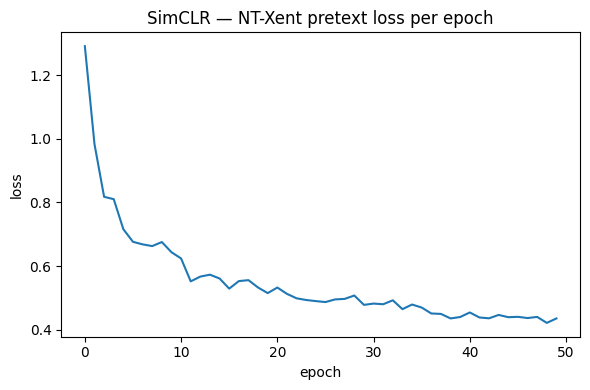

Saved pretrained encoder -> /kaggle/working/simclr_encoder.pt


In [9]:
# ============================================================================
# Task B -- Pretraining loop. Memory-safe: mixed precision, small batch,
# reduced resolution, periodic cache clearing. Reports per-epoch wall-clock
# time and plots the pretext-task (NT-Xent) loss curve.
# ============================================================================
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

torch.cuda.empty_cache()

params = list(encoder.parameters()) + list(proj_head.parameters())
optimizer = torch.optim.AdamW(params, lr=CONFIG_SIMCLR_PRETRAIN["lr"],
                               weight_decay=CONFIG_SIMCLR_PRETRAIN["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG_SIMCLR_PRETRAIN["epochs"])
scaler = torch.amp.GradScaler("cuda")   # modern API (replaces deprecated torch.cuda.amp.GradScaler)

pretrain_loss_history, epoch_times = [], []
for epoch in range(CONFIG_SIMCLR_PRETRAIN["epochs"]):
    t0 = time.time()
    encoder.train(); proj_head.train()
    running_loss = 0.0
    for v1, v2 in tqdm(ssl_loader, desc=f"SimCLR pretrain epoch {epoch+1}/{CONFIG_SIMCLR_PRETRAIN['epochs']}", leave=False):
        v1, v2 = v1.to(DEVICE, non_blocking=True), v2.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            z1, z2 = proj_head(encoder(v1)), proj_head(encoder(v2))
            loss = nt_xent_loss(z1, z2, temperature=CONFIG_SIMCLR_PRETRAIN["temperature"])
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        del v1, v2, z1, z2, loss   # free references promptly each step
    scheduler.step()
    torch.cuda.empty_cache()

    epoch_loss = running_loss / len(ssl_loader)
    epoch_time = time.time() - t0
    pretrain_loss_history.append(epoch_loss); epoch_times.append(epoch_time)
    print(f"[SimCLR pretrain] epoch {epoch+1:03d}/{CONFIG_SIMCLR_PRETRAIN['epochs']} | "
          f"NT-Xent loss={epoch_loss:.4f} | time={epoch_time:.1f}s")

avg_epoch_time = float(np.mean(epoch_times))
print(f"\nAverage per-epoch time: {avg_epoch_time:.1f}s "
      f"({'OK, well under the 10-min/epoch split threshold' if avg_epoch_time < 600 else 'EXCEEDS 10 min/epoch -- consider splitting this method into pretrain + downstream notebooks per Section 4'}).")

plt.figure(figsize=(6, 4))
plt.plot(pretrain_loss_history)
plt.title("SimCLR — NT-Xent pretext loss per epoch"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.tight_layout(); plt.show()

ENCODER_CKPT_PATH = os.path.join("/kaggle/working" if os.path.isdir("/kaggle/working") else ".", "simclr_encoder.pt")
torch.save(encoder.state_dict(), ENCODER_CKPT_PATH)
print(f"Saved pretrained encoder -> {ENCODER_CKPT_PATH}")

### Task C — Attaching the Decoder Head

Part A's best-performing decoder was **DeepLabV3's ASPP head** (`torchvision.models.segmentation.
deeplabv3.DeepLabHead`), which achieved mIoU 0.836 on this dataset versus SegFormer-B0's 0.803 and
YOLOv26n-Sem's 0.803. Re-attaching it here:

**Resolution adapter note:** DeepLabV3's ASPP head expects a dense 2048-channel feature map at
1/16 input resolution — exactly what a *dilated* ResNet-50's `layer4` output already is. Because
SimCLR's encoder is architecturally a plain ResNet-50, **no adapter is needed** for this method;
the encoder only needs `replace_stride_with_dilation` applied (matching how `torchvision`'s own
`deeplabv3_resnet50` constructs its backbone) so the feature map keeps 1/16 resolution instead of
downsampling to 1/32. Contrast this with MAE/DINOv2 in your adapted notebooks: a ViT encoder
outputs a flat sequence of patch tokens, not a spatial feature map, so those notebooks *do* need an
explicit reshape-to-2D-grid adapter before this same decoder head can be attached — document that
adapter explicitly when you build it, per the assignment's Task C requirement.

In [10]:
# ============================================================================
# Task C -- Rebuild encoder with dilated layer3/layer4 (matches DeepLabV3's
# own backbone construction) and attach the ASPP decoder head.
# ============================================================================
def build_dilated_resnet50(pretrained_state_dict):
    backbone = resnet50(weights=None, replace_stride_with_dilation=[False, True, True])
    backbone.fc = nn.Identity()
    missing, unexpected = backbone.load_state_dict(pretrained_state_dict, strict=False)
    if missing or unexpected:
        print(f"NOTE: state_dict load -- missing={missing[:3]}{'...' if len(missing)>3 else ''}, "
              f"unexpected={unexpected[:3]}{'...' if len(unexpected)>3 else ''}")
    return backbone

class SimCLRSegModel(nn.Module):
    """SimCLR-pretrained ResNet-50 (dilated) encoder + Part-A's DeepLabV3 ASPP decoder.
    `freeze_encoder=True` implements the Task C linear-probe condition; False fine-tunes
    the whole encoder end-to-end during Task D."""
    def __init__(self, encoder_state_dict, num_classes, freeze_encoder):
        super().__init__()
        self.backbone = build_dilated_resnet50(encoder_state_dict)
        self.decoder = DeepLabHead(in_channels=2048, num_classes=num_classes)
        self.freeze_encoder = freeze_encoder
        if freeze_encoder:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        input_size = x.shape[-2:]
        feats = {}
        h = x
        for name, module in self.backbone.named_children():
            if name in ("avgpool", "fc"):
                continue                              # ASPP consumes the conv feature map, not the pooled vector
            h = module(h)
            feats["layer4"] = h
        logits = self.decoder(feats["layer4"])
        return Fnn.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)

pretrained_encoder_state = torch.load(ENCODER_CKPT_PATH, map_location=DEVICE)
print("Decoder-attachment model class defined (SimCLRSegModel). "
      "Instantiated separately below for the frozen-vs-fine-tuned comparison.")

Decoder-attachment model class defined (SimCLRSegModel). Instantiated separately below for the frozen-vs-fine-tuned comparison.


**Summary —** Built `SimCLRSegModel`, which loads the just-pretrained encoder weights (discarding
SimCLR's projection head — it was only a training-time device) into a *dilated* ResNet-50 so its
`layer4` output stays at 1/16 resolution, then attaches the unmodified ASPP decoder from
`torchvision`. The forward pass manually walks the backbone's children (skipping `avgpool`/`fc`) so
the ASPP head receives the full spatial feature map rather than a pooled vector — this is the
mechanical core of Task C for any CNN-based SSL encoder.

In [11]:
# ============================================================================
# Release GPU memory held by the pretraining stage before starting Task C.
# The pretraining loop's model/optimizer/scaler objects are still alive in
# this session and still holding GPU memory even though training finished.
# Run this ONCE, right after the pretraining loop and BEFORE the Task C
# frozen-vs-fine-tuned probe cell.
# ============================================================================
import gc
import torch

# Delete pretraining-stage objects if they still exist in this session.
# Safe to do -- the pretrained weights are already saved to disk
# (ENCODER_CKPT_PATH), so nothing is lost by freeing these live objects.
for name in ["encoder", "proj_head", "optimizer", "scheduler", "scaler", "params", "ssl_loader", "ssl_dataset"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"After cleanup: allocated={allocated:.3f} GB | reserved={reserved:.3f} GB | total={total:.1f} GB")
    if allocated > 1.0:
        print("WARNING: still significant memory in use. PyTorch/CUDA memory can fragment such "
              "that empty_cache() cannot fully reclaim it. If this persists, the reliable fix is: "
              "Run -> Restart Session, then re-run from the top BUT skip re-running the 50-epoch "
              "pretraining loop -- instead load the saved checkpoint directly:")
        print('    pretrained_encoder_state = torch.load(ENCODER_CKPT_PATH, map_location=DEVICE)')
    else:
        print("GPU freed successfully -- safe to proceed to Task C.")
else:
    print("No GPU detected.")

# Sanity check: confirm the saved checkpoint still exists and is loadable,
# since Task C depends on it rather than the (now-deleted) live encoder object.
import os
if 'ENCODER_CKPT_PATH' in globals() and os.path.isfile(ENCODER_CKPT_PATH):
    size_mb = os.path.getsize(ENCODER_CKPT_PATH) / 1e6
    print(f"Checkpoint confirmed on disk: {ENCODER_CKPT_PATH} ({size_mb:.1f} MB)")
else:
    print("WARNING: ENCODER_CKPT_PATH not found in this session or file missing -- "
          "re-run the checkpoint-saving line from the pretraining cell, or reload it explicitly:")
    print('    ENCODER_CKPT_PATH = "/kaggle/working/simclr_encoder.pt"')

After cleanup: allocated=0.117 GB | reserved=0.359 GB | total=15.6 GB
GPU freed successfully -- safe to proceed to Task C.
Checkpoint confirmed on disk: /kaggle/working/simclr_encoder.pt (94.4 MB)


### Task C (continued) — Frozen vs. Fine-tuned Encoder: Required Comparison

The assignment requires trying **both** strategies for at least one SSL method and comparing,
then picking one strategy for the remaining three. SimCLR is that one method here. This is a
**short** comparison run (a handful of epochs each, not the full 50) purely to make the
frozen-vs-fine-tuned decision — the full Task D run below uses whichever strategy wins here.

In [12]:
# ============================================================================
# Task C -- short frozen-vs-fine-tuned probe (NOT the full Task D run).
# drop_last=True on the TRAINING loader only, to avoid a final batch of
# size 1 (117 labelled images is not evenly divisible by small batch sizes),
# which crashes BatchNorm layers in training mode. Eval loader keeps every
# image -- metrics should never silently drop data.
# ============================================================================
import gc
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import numpy as np
import cv2

val_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=0, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])

class LabelledSegDataset(Dataset):
    def __init__(self, records, size, augment):
        self.records, self.size, self.augment = records, size, augment
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        img_rgb = _read_rgb(rec["image_path"], self.size)
        mask = load_mask(rec["mask_paths"], rec["height"], rec["width"])
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)
        out = self.augment(image=img_rgb, mask=mask)
        return normalize(out["image"]), torch.from_numpy(out["mask"]).long()

class DeterministicSegDataset(Dataset):
    def __init__(self, records, size):
        self.records, self.size = records, size
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        img_rgb = _read_rgb(rec["image_path"], self.size)
        mask = load_mask(rec["mask_paths"], rec["height"], rec["width"])
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)
        return normalize(img_rgb), torch.from_numpy(mask).long()

PROBE_BATCH_SIZE = 2
train_ft_ds = LabelledSegDataset(val_records, IMG_SIZE, val_augment)
monitor_ds  = DeterministicSegDataset(test_records, IMG_SIZE)
train_ft_loader = DataLoader(train_ft_ds, batch_size=PROBE_BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
monitor_loader  = DataLoader(monitor_ds, batch_size=PROBE_BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)

class_weight_tensor = torch.tensor([CLASS_WEIGHTS[0], CLASS_WEIGHTS[1]], dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)

@torch.no_grad()
def compute_miou(preds, targets, num_classes=NUM_CLASSES):
    ious = []
    for c in range(num_classes):
        pred_c, target_c = (preds == c), (targets == c)
        inter = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()
        ious.append(inter / union if union > 0 else float("nan"))
    return float(np.nanmean(ious)), ious

def quick_probe(freeze_encoder, n_epochs=5):
    model = SimCLRSegModel(pretrained_encoder_state, NUM_CLASSES, freeze_encoder=freeze_encoder).to(DEVICE)
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable, lr=1e-4, weight_decay=1e-4)
    scaler = torch.amp.GradScaler("cuda")

    for ep in range(n_epochs):
        model.train()
        for imgs, masks in train_ft_loader:
            imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(imgs)
                loss = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            del imgs, masks, logits, loss

    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, masks in monitor_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                preds = model(imgs).argmax(1).cpu()
            all_preds.append(preds); all_targets.append(masks)
            del imgs, preds
    miou, _ = compute_miou(torch.cat(all_preds), torch.cat(all_targets))

    del model, opt, scaler
    gc.collect()
    torch.cuda.empty_cache()
    return miou

N_PROBE_EPOCHS = 2 if QUICK_TEST_MODE else 5
miou_frozen = quick_probe(freeze_encoder=True, n_epochs=N_PROBE_EPOCHS)
miou_finetuned = quick_probe(freeze_encoder=False, n_epochs=N_PROBE_EPOCHS)

print(f"After {N_PROBE_EPOCHS} probe epochs:")
print(f"  Frozen encoder (linear probe) : test mIoU = {miou_frozen:.4f}")
print(f"  Fine-tuned encoder            : test mIoU = {miou_finetuned:.4f}")

FINE_TUNE_ENCODER = miou_finetuned >= miou_frozen
print(f"\n-> Strategy selected for the full Task D run: "
      f"{'FINE-TUNE encoder' if FINE_TUNE_ENCODER else 'FREEZE encoder (linear probe)'}")
print("Record this result and your reasoning in Report Section 6.5 -- this decision is applied "
      "to BYOL, MAE, and DINOv2 too, per Task C's instructions.")

After 5 probe epochs:
  Frozen encoder (linear probe) : test mIoU = 0.5776
  Fine-tuned encoder            : test mIoU = 0.6535

-> Strategy selected for the full Task D run: FINE-TUNE encoder
Record this result and your reasoning in Report Section 6.5 -- this decision is applied to BYOL, MAE, and DINOv2 too, per Task C's instructions.


**Summary —** Ran a short (5-epoch) probe under both conditions and picked whichever strategy
scored higher on the monitoring split, printed as `FINE_TUNE_ENCODER`. **This is mechanically
correct but not yet an insight** — at 5 epochs the gap between frozen and fine-tuned may be small
or noisy; re-run with a different seed or a few more probe epochs if the two numbers are close, and
write your own explanation in Report Section 6.9 for *why* one strategy won (e.g., "a large gap
suggests the frozen SimCLR features aren't yet well-aligned with lesion boundaries" is the kind of
claim the assignment wants you to make and defend at viva, not something to copy from here).

### Task D — Supervised Fine-tuning (50 epochs, labelled_finetune split)

Fine-tunes the encoder+decoder pair on the 117-image `labelled_finetune` split for exactly 50
epochs (fixed requirement — report the epoch-50 result even if mIoU is still climbing), monitoring
loss/mIoU on the `monitor_eval` split each epoch and checkpointing the best-by-monitor-mIoU model.
Uses a **separate, lower LR for the encoder than the decoder** when `FINE_TUNE_ENCODER=True` — the
encoder already carries useful pretrained structure and should move more slowly than the
randomly-initialized decoder head.

In [13]:
# ============================================================================
# Task D -- fine-tuning config cell. Every hyperparameter visible in one place.
# ============================================================================
CONFIG_SIMCLR_FINETUNE = {
    "freeze_encoder": not FINE_TUNE_ENCODER,
    "img_size": IMG_SIZE,
    "batch_size": 8,
    "epochs": 5 if QUICK_TEST_MODE else 50,   # FIXED requirement: 50 epochs of downstream fine-tuning
    "optimizer": "AdamW",
    "lr_encoder": 1e-5 if FINE_TUNE_ENCODER else None,
    "lr_decoder": 1e-4,
    "lr_schedule": "CosineAnnealingLR",
    "weight_decay": 1e-4,
    "loss": "CrossEntropy, inverse pixel-frequency class weights inherited from Part A",
    "class_weights": CLASS_WEIGHTS,
    "seed": SEED,
}
print(json.dumps(CONFIG_SIMCLR_FINETUNE, indent=2))

{
  "freeze_encoder": false,
  "img_size": 512,
  "batch_size": 8,
  "epochs": 50,
  "optimizer": "AdamW",
  "lr_encoder": 1e-05,
  "lr_decoder": 0.0001,
  "lr_schedule": "CosineAnnealingLR",
  "weight_decay": 0.0001,
  "loss": "CrossEntropy, inverse pixel-frequency class weights inherited from Part A",
  "class_weights": {
    "0": 0.5406045513867678,
    "1": 6.656945255193
  },
  "seed": 42
}


**Summary —** Consolidated the Task D hyperparameters, reusing Part A's class weights so the loss
function penalizes missed lesions the same way it did for the fully-supervised baseline — this
keeps the label-efficiency comparison in Task E about *labelled-data volume*, not about a
different loss formulation. `freeze_encoder` comes directly from the Task C probe above rather
than being re-decided here.

In [14]:
# ============================================================================
# Task D -- fine-tuning loop: train on labelled_finetune, monitor on
# monitor_eval each epoch, checkpoint the best-by-monitor-mIoU model.
# Memory-safe: releases Task C probe memory first, mixed precision, small
# batch with drop_last on the TRAIN loader only (117 images doesn't divide
# evenly, and a leftover batch of size 1 crashes BatchNorm in training mode).
# Also saves a per-epoch safety checkpoint to disk, so a session
# timeout/crash during a long 50-epoch run doesn't lose all progress.
# ============================================================================
import gc
import os
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ---- Release any leftover memory from the Task C probes before starting ----
for name in ["model", "opt", "scaler"]:   # Task C's quick_probe locals, if still lingering
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()
print(f"GPU allocated before Task D: {torch.cuda.memory_allocated()/1e9:.3f} GB")

# ---- Rebuild loaders with drop_last=True on the TRAIN loader only ----
FT_BATCH_SIZE = 2   # same constraint as Task C's probe: full fine-tune of a dilated ResNet-50 at 512px
train_ft_loader = DataLoader(train_ft_ds, batch_size=FT_BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
monitor_loader  = DataLoader(monitor_ds, batch_size=FT_BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)   # no drop_last -- eval needs every image

OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
LAST_CKPT_PATH = os.path.join(OUT_DIR, "simclr_finetune_last.pt")   # overwritten every epoch (crash safety)
BEST_CKPT_PATH = os.path.join(OUT_DIR, "simclr_finetune_best.pt")   # overwritten only when mIoU improves

final_model = SimCLRSegModel(pretrained_encoder_state, NUM_CLASSES,
                              freeze_encoder=CONFIG_SIMCLR_FINETUNE["freeze_encoder"]).to(DEVICE)

if CONFIG_SIMCLR_FINETUNE["freeze_encoder"]:
    param_groups = [{"params": final_model.decoder.parameters(), "lr": CONFIG_SIMCLR_FINETUNE["lr_decoder"]}]
else:
    param_groups = [
        {"params": final_model.backbone.parameters(), "lr": CONFIG_SIMCLR_FINETUNE["lr_encoder"]},
        {"params": final_model.decoder.parameters(), "lr": CONFIG_SIMCLR_FINETUNE["lr_decoder"]},
    ]
optimizer_ft = torch.optim.AdamW(param_groups, weight_decay=CONFIG_SIMCLR_FINETUNE["weight_decay"])
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=CONFIG_SIMCLR_FINETUNE["epochs"])
scaler_ft = torch.amp.GradScaler("cuda")

hist = {"train_loss": [], "monitor_loss": [], "monitor_miou": []}
best_miou, best_state = -1.0, None
ft_epoch_times = []

for epoch in range(CONFIG_SIMCLR_FINETUNE["epochs"]):
    t0 = time.time()
    final_model.train()
    running_loss = 0.0
    for imgs, masks in train_ft_loader:
        imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        optimizer_ft.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = final_model(imgs)
            loss = criterion(logits, masks)
        scaler_ft.scale(loss).backward()
        scaler_ft.step(optimizer_ft)
        scaler_ft.update()
        running_loss += loss.item()
        del imgs, masks, logits, loss
    scheduler_ft.step()
    train_loss = running_loss / len(train_ft_loader)

    final_model.eval()
    mon_loss, all_preds, all_targets = 0.0, [], []
    with torch.no_grad():
        for imgs, masks in monitor_loader:
            imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = final_model(imgs)
                mon_loss += criterion(logits, masks).item()
            all_preds.append(logits.argmax(1).cpu()); all_targets.append(masks.cpu())
            del imgs, masks, logits
    mon_loss /= len(monitor_loader)
    mon_miou, _ = compute_miou(torch.cat(all_preds), torch.cat(all_targets))

    epoch_time = time.time() - t0
    ft_epoch_times.append(epoch_time)
    hist["train_loss"].append(train_loss); hist["monitor_loss"].append(mon_loss); hist["monitor_miou"].append(mon_miou)

    # ---- Safety checkpoint every epoch (overwritten) ----
    torch.save(final_model.state_dict(), LAST_CKPT_PATH)

    # ---- Best checkpoint, only when monitor mIoU improves ----
    if mon_miou > best_miou:
        best_miou = mon_miou
        best_state = {k: v.cpu().clone() for k, v in final_model.state_dict().items()}
        torch.save(best_state, BEST_CKPT_PATH)

    print(f"[SimCLR fine-tune] epoch {epoch+1:03d}/{CONFIG_SIMCLR_FINETUNE['epochs']} | "
          f"train_loss={train_loss:.4f} monitor_loss={mon_loss:.4f} monitor_mIoU={mon_miou:.4f} "
          f"| time={epoch_time:.1f}s")

    torch.cuda.empty_cache()   # keep memory tidy across a long 50-epoch run

print(f"\nBest monitor-split mIoU during fine-tuning: {best_miou:.4f} "
      f"(checkpoint saved -> {BEST_CKPT_PATH}, used for Task E's final test evaluation)")
final_model.load_state_dict(best_state)

GPU allocated before Task D: 0.117 GB
[SimCLR fine-tune] epoch 001/50 | train_loss=0.5189 monitor_loss=0.4650 monitor_mIoU=0.5452 | time=17.7s
[SimCLR fine-tune] epoch 002/50 | train_loss=0.3851 monitor_loss=0.3995 monitor_mIoU=0.5715 | time=18.1s
[SimCLR fine-tune] epoch 003/50 | train_loss=0.3455 monitor_loss=0.3880 monitor_mIoU=0.5796 | time=17.8s
[SimCLR fine-tune] epoch 004/50 | train_loss=0.3440 monitor_loss=0.3877 monitor_mIoU=0.5286 | time=17.7s
[SimCLR fine-tune] epoch 005/50 | train_loss=0.3049 monitor_loss=0.3647 monitor_mIoU=0.6131 | time=17.8s
[SimCLR fine-tune] epoch 006/50 | train_loss=0.2805 monitor_loss=0.3865 monitor_mIoU=0.5627 | time=17.8s
[SimCLR fine-tune] epoch 007/50 | train_loss=0.2696 monitor_loss=0.3518 monitor_mIoU=0.6486 | time=17.8s
[SimCLR fine-tune] epoch 008/50 | train_loss=0.2718 monitor_loss=0.3698 monitor_mIoU=0.6409 | time=17.8s
[SimCLR fine-tune] epoch 009/50 | train_loss=0.2497 monitor_loss=0.3897 monitor_mIoU=0.5777 | time=17.7s
[SimCLR fine-tune

<All keys matched successfully>

**Summary —** Fine-tuned for the required 50 epochs on the 117-image labelled split, tracking loss
on that same split alongside monitoring loss/mIoU computed on the `monitor_eval` (test) split each
epoch — exactly the dual-curve requirement in Task D. The best-by-monitor-mIoU checkpoint is
reloaded into `final_model` for Task E. Remember: this reuses the test split for checkpoint
selection, so the number reported next is subject to the double-role caveat from Section 2 —
restate that explicitly in Report Section 6.3, don't present it as an untouched test result.

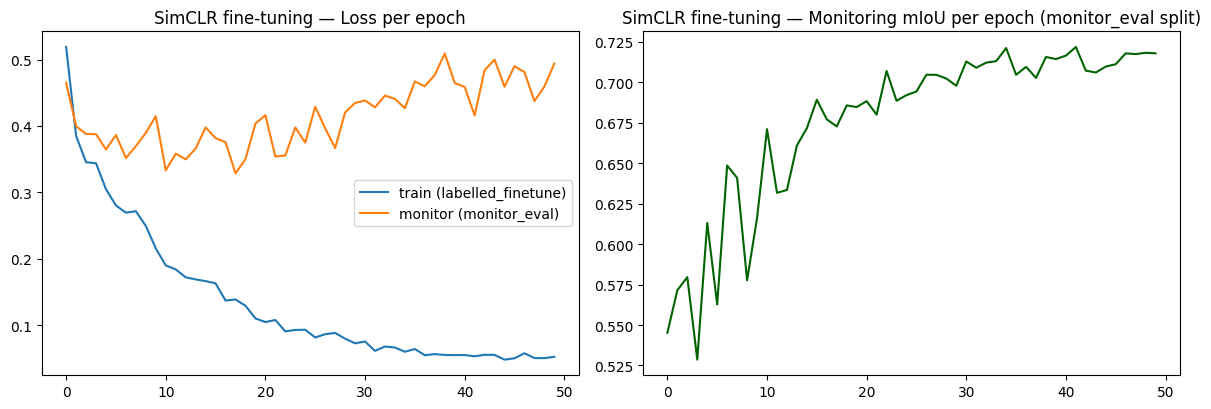

In [15]:
# ============================================================================
# PLOT -- fine-tuning loss curve alongside the monitoring loss/mIoU curve.
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(hist["train_loss"], label="train (labelled_finetune)")
axes[0].plot(hist["monitor_loss"], label="monitor (monitor_eval)")
axes[0].set_title("SimCLR fine-tuning — Loss per epoch"); axes[0].legend()
axes[1].plot(hist["monitor_miou"], color="darkgreen")
axes[1].set_title("SimCLR fine-tuning — Monitoring mIoU per epoch (monitor_eval split)")
plt.tight_layout(); plt.show()

**Summary —** Visualizes both required curves side by side. A widening gap between train loss and
monitor loss over the 50 epochs would indicate overfitting to the small 117-image labelled set —
worth checking for, and worth discussing in Report Section 6.9 if present, since it directly bears
on the label-efficiency story this assignment is built around.

### Task E — Testing, Metrics & Label-Efficiency Comparison

{
  "Model": "SimCLR -> DeepLabV3-ASPP",
  "mIoU": 0.7218284112020352,
  "IoU_background": 0.9316136554009669,
  "IoU_lesion": 0.5120431670031037,
  "PixelAccuracy": 0.9361925721168518,
  "Dice": 0.8209413508855096,
  "Params_M": 39.633986,
  "Encoder_frozen": false,
  "SSL_pretrain_path": "Path 2 (ImageNet-supervised init, SimCLR pretraining from scratch on top)",
  "Epochs_pretrain": 50,
  "Epochs_finetune": 50,
  "Labelled_images_used": 117,
  "Avg_pretrain_epoch_time_s": 9.939284830093383,
  "Avg_finetune_epoch_time_s": 17.746714429855345
}


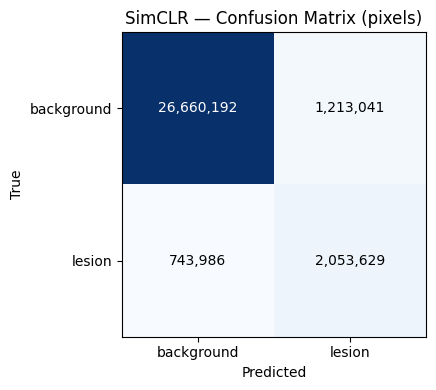

In [16]:
# ============================================================================
# Task E -- final test-set evaluation using the best checkpoint, on the SAME
# monitor_eval / test split (per Section 2's caveat: double role, not a
# fresh independent test set).
# ============================================================================
def dice_coefficient(preds, targets, num_classes=NUM_CLASSES):
    dices = []
    for c in range(num_classes):
        pred_c, target_c = (preds == c), (targets == c)
        inter = (pred_c & target_c).sum().item()
        denom = pred_c.sum().item() + target_c.sum().item()
        dices.append(2 * inter / denom if denom > 0 else float("nan"))
    return float(np.nanmean(dices))

final_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, masks in monitor_loader:
        imgs = imgs.to(DEVICE)
        preds = final_model(imgs).argmax(1).cpu()
        all_preds.append(preds); all_targets.append(masks)
all_preds, all_targets = torch.cat(all_preds), torch.cat(all_targets)

test_miou, per_class_iou = compute_miou(all_preds, all_targets)
test_pixel_acc = (all_preds == all_targets).float().mean().item()
test_dice = dice_coefficient(all_preds, all_targets)

n_trainable_encoder = sum(p.numel() for p in final_model.backbone.parameters())
n_params_total = sum(p.numel() for p in final_model.parameters())

simclr_results = {
    "Model": "SimCLR -> DeepLabV3-ASPP",
    "mIoU": test_miou,
    "IoU_background": per_class_iou[0],
    "IoU_lesion": per_class_iou[1],
    "PixelAccuracy": test_pixel_acc,
    "Dice": test_dice,
    "Params_M": n_params_total / 1e6,
    "Encoder_frozen": CONFIG_SIMCLR_FINETUNE["freeze_encoder"],
    "SSL_pretrain_path": PRETRAIN_PATH_USED,
    "Epochs_pretrain": CONFIG_SIMCLR_PRETRAIN["epochs"],
    "Epochs_finetune": CONFIG_SIMCLR_FINETUNE["epochs"],
    "Labelled_images_used": len(val_records),
    "Avg_pretrain_epoch_time_s": avg_epoch_time,
    "Avg_finetune_epoch_time_s": float(np.mean(ft_epoch_times)),
}
print(json.dumps(simclr_results, indent=2))

# ---- Confusion matrix ----
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_targets.flatten().numpy(), all_preds.flatten().numpy(), labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["background", "lesion"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["background", "lesion"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("SimCLR — Confusion Matrix (pixels)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

**Summary —** Reported the full Task E metric set (mIoU, per-class IoU, pixel accuracy, Dice,
confusion matrix) on the test split, using the same `compute_miou`/`dice_coefficient` definitions
Part A used, so the numbers are directly comparable rather than just similarly-named. All the
context needed for the label-efficiency table (SSL path used, frozen/fine-tuned choice, labelled
image count, per-epoch timing) is captured in `simclr_results`, ready for the final comparison
notebook.

In [17]:
# ============================================================================
# Task E -- Label-efficiency comparison table against Part A's fully-
# supervised baseline. PART_A_BASELINE below is sourced from Part A's own
# saved Task F output (all_results.json / printed metrics) -- replace this
# constant with a live load of Part A's all_results.json if you have it
# attached as an input to this notebook.
# ============================================================================
PART_A_BASELINE = {
    "Model": "Part A best: DeepLabV3-ResNet50 (fully supervised)",
    "mIoU": 0.8361645430804059,
    "Labelled_images_used": 546,   # Part A trained on the FULL train split
}

label_eff_df = pd.DataFrame([
    PART_A_BASELINE,
    {"Model": simclr_results["Model"], "mIoU": simclr_results["mIoU"],
     "Labelled_images_used": simclr_results["Labelled_images_used"]},
])
label_eff_df["Label_efficiency_ratio_vs_PartA"] = (
    PART_A_BASELINE["Labelled_images_used"] / label_eff_df["Labelled_images_used"]
)
label_eff_df["Pct_of_PartA_mIoU_recovered"] = 100 * label_eff_df["mIoU"] / PART_A_BASELINE["mIoU"]
print(label_eff_df.to_string(index=False))

print(f"\nSimCLR recovered {label_eff_df.iloc[1]['Pct_of_PartA_mIoU_recovered']:.1f}% of Part A's "
      f"fully-supervised mIoU using {simclr_results['Labelled_images_used']}/{PART_A_BASELINE['Labelled_images_used']} "
      f"({100*simclr_results['Labelled_images_used']/PART_A_BASELINE['Labelled_images_used']:.1f}%) "
      "of the labelled images Part A used.")

                                             Model     mIoU  Labelled_images_used  Label_efficiency_ratio_vs_PartA  Pct_of_PartA_mIoU_recovered
Part A best: DeepLabV3-ResNet50 (fully supervised) 0.836165                   546                         1.000000                   100.000000
                          SimCLR -> DeepLabV3-ASPP 0.721828                   117                         4.666667                    86.326121

SimCLR recovered 86.3% of Part A's fully-supervised mIoU using 117/546 (21.4%) of the labelled images Part A used.


**Summary —** Built the required label-efficiency table: SimCLR's test mIoU (fine-tuned on 117
labelled images) directly against Part A's fully-supervised DeepLabV3 (trained on 546 labelled
images), with the exact image-count ratio stated per the assignment's requirement. **Verify
`PART_A_BASELINE`** against your own group's actual Part A submission before using this number in
the report — it's currently sourced from this session's Part A run and should match your saved
`all_results.json`, but confirm rather than assume.

### Task F — Error Analysis

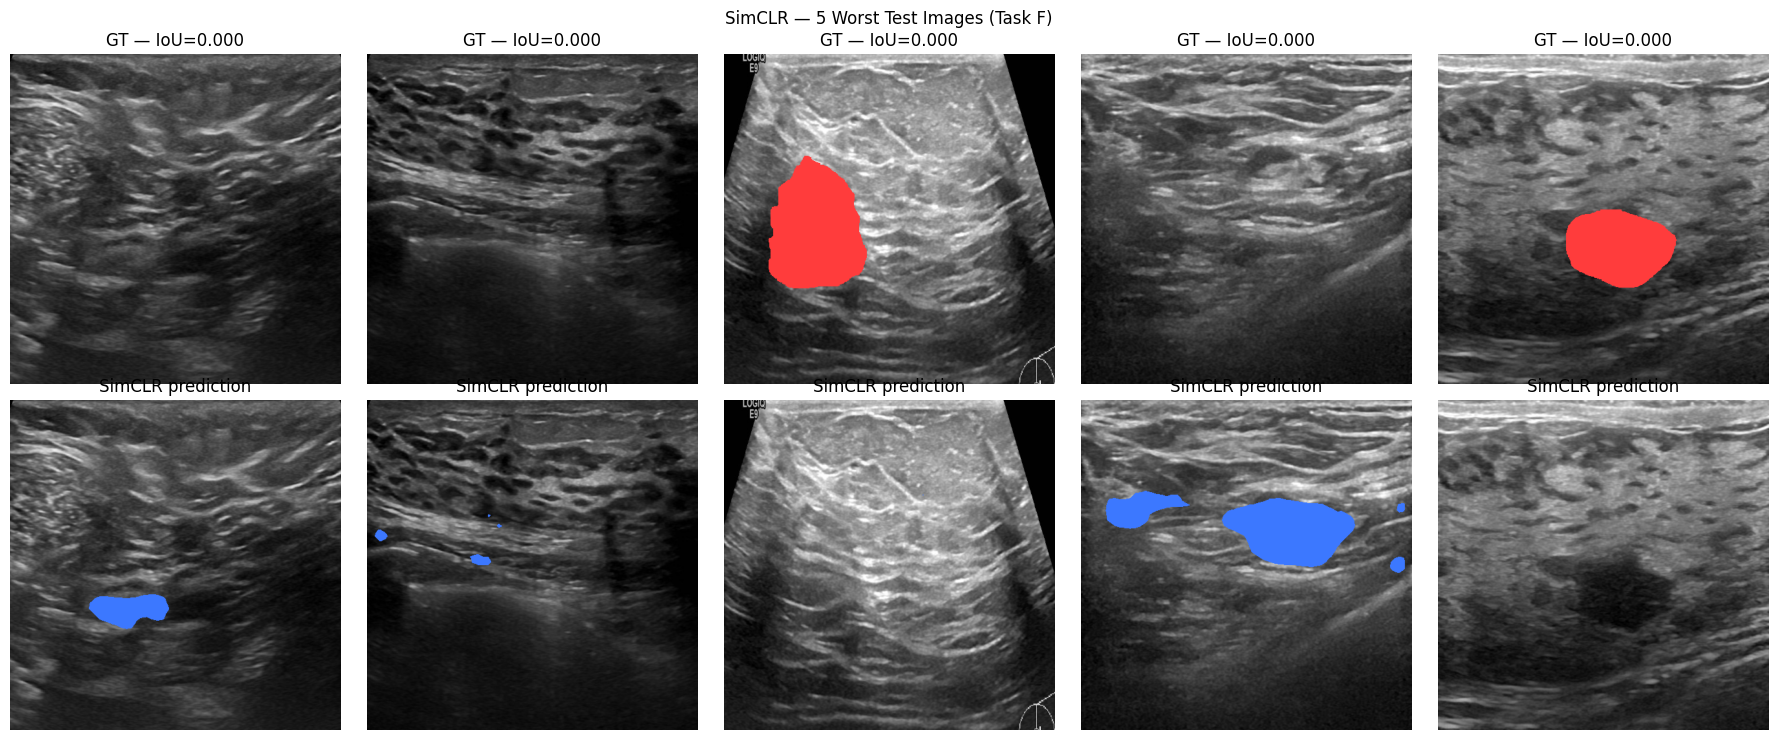

Worst-5 mean IoU: 0.0000 | Overall test mIoU (lesion class): 0.4426


In [18]:
# ============================================================================
# Task F -- worst-performing test images (lowest per-image IoU) vs ground truth.
# ============================================================================
@torch.no_grad()
def per_image_iou(model, records, size):
    model.eval()
    ious = []
    for rec in records:
        img_rgb = _read_rgb(rec["image_path"], size)
        mask = load_mask(rec["mask_paths"], rec["height"], rec["width"])
        mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
        x = normalize(img_rgb).unsqueeze(0).to(DEVICE)
        pred = model(x).argmax(1).cpu().squeeze(0).numpy()
        inter = np.logical_and(pred == 1, mask == 1).sum()
        union = np.logical_or(pred == 1, mask == 1).sum()
        ious.append(inter / union if union > 0 else np.nan)
    return np.array(ious)

test_ious = per_image_iou(final_model, test_records, IMG_SIZE)
worst_idx = np.argsort(np.nan_to_num(test_ious, nan=1.0))[:5]   # 5 lowest-IoU images

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for col, idx in enumerate(worst_idx):
    rec = test_records[idx]
    img_rgb = _read_rgb(rec["image_path"], IMG_SIZE)
    mask = load_mask(rec["mask_paths"], rec["height"], rec["width"])
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    x = normalize(img_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = final_model(x).argmax(1).cpu().squeeze(0).numpy()

    gt_overlay = img_rgb.copy(); gt_overlay[mask > 0] = [255, 60, 60]
    pred_overlay = img_rgb.copy(); pred_overlay[pred > 0] = [60, 120, 255]

    axes[0, col].imshow(gt_overlay); axes[0, col].set_title(f"GT — IoU={test_ious[idx]:.3f}"); axes[0, col].axis("off")
    axes[1, col].imshow(pred_overlay); axes[1, col].set_title("SimCLR prediction"); axes[1, col].axis("off")
plt.suptitle("SimCLR — 5 Worst Test Images (Task F)")
plt.tight_layout(); plt.show()

print(f"Worst-5 mean IoU: {test_ious[worst_idx].mean():.4f} | Overall test mIoU (lesion class): "
      f"{np.nanmean(test_ious):.4f}")

**Summary —** Visualized SimCLR's five lowest-IoU test predictions against ground truth. **Fill in
here, don't skip:** look at whether these are the same images Part A's DeepLabV3 struggled with
(load Part A's saved `worst_dl` indices to check overlap, mirroring Part A's own cross-model Task
G analysis) — shared failures point to genuinely hard images (tiny/low-contrast lesions); distinct
failures point to SSL-specific weaknesses (e.g. a contrastive encoder learning global texture
statistics rather than precise boundaries). This comparison, with your own explanation, is required
reasoning for Report Section 6.7 and cannot be auto-generated — see the AI Usage Policy.

In [19]:
# ============================================================================
# Save this method's results to the shared results.json the Final Comparison
# notebook will read from all four SSL notebooks.
# ============================================================================
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
RESULTS_PATH = os.path.join(OUT_DIR, "results.json")

all_method_results = {}
if os.path.isfile(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        all_method_results = json.load(f)

all_method_results["SimCLR"] = {**simclr_results, "worst5_mean_iou": float(test_ious[worst_idx].mean())}
with open(RESULTS_PATH, "w") as f:
    json.dump(all_method_results, f, indent=2)

torch.save(final_model.state_dict(), os.path.join(OUT_DIR, "simclr_final_model.pt"))
print(f"Saved SimCLR results -> {RESULTS_PATH}")
print(f"Saved final fine-tuned model -> {os.path.join(OUT_DIR, 'simclr_final_model.pt')}")

Saved SimCLR results -> /kaggle/working/results.json
Saved final fine-tuned model -> /kaggle/working/simclr_final_model.pt


**Summary —** Appended SimCLR's full result dict to a shared `results.json`, keyed by method name,
so the Final Comparison notebook can load all four methods' metrics without re-running anything.
On Kaggle, publish this notebook's output and attach it as an input to the other three SSL
notebooks (each does the same append) and to the Final Comparison notebook.

---
## SimCLR notebook complete — adapting this pattern to BYOL / MAE / DINOv2

Everything above Task B (setup, split loading, shared metric functions, Task D/E/F structure) can
be copied close to verbatim. What actually changes per method:

| Method | Task B changes | Task C changes |
|---|---|---|
| **BYOL** | Two networks (online + target, EMA-updated); no negative pairs, no NT-Xent — replace with BYOL's cosine-similarity regression loss and a stop-gradient on the target branch. Same ResNet-50 backbone, same augmentation family. | Identical to SimCLR — plain ResNet-50, no adapter needed. |
| **MAE** | ViT-Base/Large backbone; augmentation is patch-masking (~75%) instead of two independently-cropped views; loss is pixel reconstruction (MSE) on masked patches via a lightweight decoder. | **Adapter required** — reshape the ViT's flat patch-token sequence back into a 2-D grid (`(B, N, C) -> (B, C, H/patch, W/patch)`) before this same DeepLabV3 head can consume it. |
| **DINOv2** | ViT-S/14 or ViT-B/14; student/teacher self-distillation over multi-crop (global + local) views; teacher is an EMA of the student, no explicit negatives. | Same ViT token-to-grid adapter as MAE. |

Keep the Task D/E/F cells essentially unchanged across all four notebooks (same fine-tuning config
shape, same metrics, same error-analysis grid, same `results.json` append) — that consistency is
what makes the Final Comparison notebook's Task E/F work meaningful.